# Project 6: FitzHugh-Nagumo and excitability

MCSB Bootcamp — Mathematical and Computational Track

Jun Allard

## Background, model, and Part I

The phenomenon of excitability exists in many biological systems,
including in the electrophysiology of neurons. The FitzHugh-Nagumo
equations

$$\begin{aligned}
\frac{dv}{dt} &= v - \frac{1}{3} v^3 - w \\
\frac{dw}{dt} &= \epsilon \left( v + a - bw\right)
\end{aligned}$$

describe neuron electrophysiology where, roughly speaking, $v$ is the
electrical potential (voltage) across the cell’s membrane, and $w$ is
the activity of ion pumps. The parameters $\epsilon$, $a$ and $b$
represent properties of the ion pumps. The model has been
nondimensionalized. Both $v$ and $w$ can be negative or positive.

a.  Confirm that for $\epsilon=0.08$, $a=0.5$, $b=0.2$, the system is
    oscillatory.

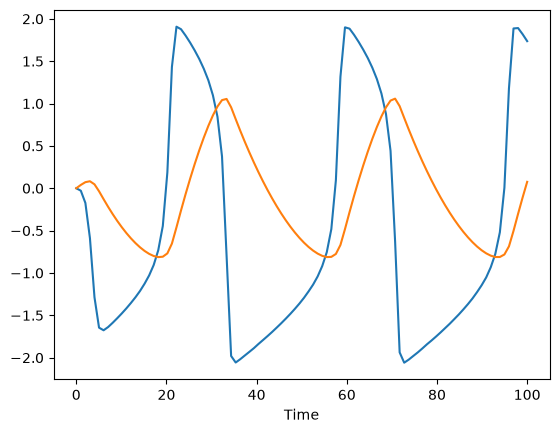

In [5]:
# Your code here.

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

e = 0.08
a = 0.5
b = 0.2
t_max = 100

def rhs(t,state):
    v,w = state
    dv_dt = v - (1/3)*v**3 - w
    dw_dt = e*(v+a-b*w)

    return dv_dt, dw_dt

sol = solve_ivp(rhs, [0,t_max], [0,0], t_eval=np.linspace(0,100,100))    

T = sol.t
v,w = sol.y

fig, ax = plt.subplots()
ax.plot(T,v,label = 'v')
ax.plot(T,w,label = 'w')
ax.set_ylabel("")
ax.set_xlabel("Time")
plt.show()



b.  Confirm that for $\epsilon=0.08$, $a=1.0$, $b=0.2$, the system has
    the following property: if you choose initial conditions
    $v(0)=-1.5$, $w(0)=-0.5$, the system evolves directly towards a
    stable steady state, but if you choose initial conditions
    $v(0)=0.0$, $w(0)=-0.5$, the system moves away from the steady state
    before eventually converging towards it. This behavior is called
    *excitability*. At these parameters, what is the steady state value
    of $v$ and $w$?

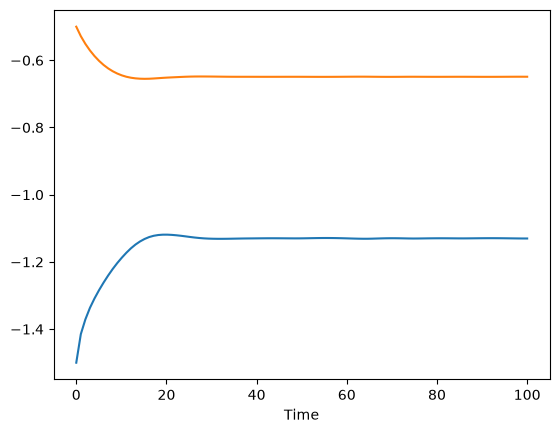

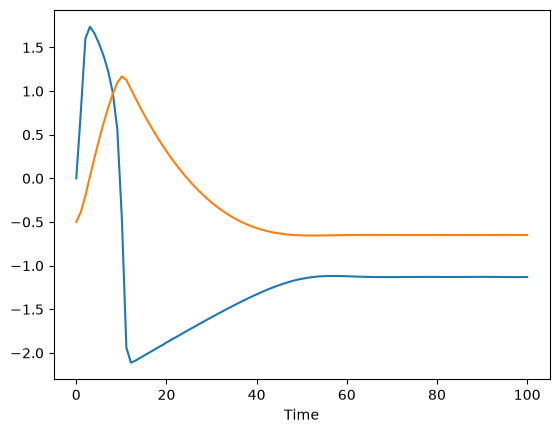

In [7]:
# Your code here.

e = 0.08
a = 1.0
b = 0.2
t_max = 100

def rhs(t,state):
    v,w = state
    dv_dt = v - (1/3)*v**3 - w
    dw_dt = e*(v+a-b*w)

    return dv_dt, dw_dt

sol = solve_ivp(rhs, [0,t_max], [-1.5,-0.5], t_eval=np.linspace(0,100,100))    

T = sol.t
v,w = sol.y

fig, ax = plt.subplots()
ax.plot(T,v,label = 'v')
ax.plot(T,w,label = 'w')
ax.set_ylabel("")
ax.set_xlabel("Time")
plt.show()

######

e = 0.08
a = 1.0
b = 0.2
t_max = 100

def rhs(t,state):
    v,w = state
    dv_dt = v - (1/3)*v**3 - w
    dw_dt = e*(v+a-b*w)

    return dv_dt, dw_dt

sol = solve_ivp(rhs, [0,t_max], [0,-0.5], t_eval=np.linspace(0,100,100))    

T = sol.t
v,w = sol.y

fig, ax = plt.subplots()
ax.plot(T,v,label = 'v')
ax.plot(T,w,label = 'w')
ax.set_ylabel("")
ax.set_xlabel("Time")
plt.show()


## Part II: Current injection

Assume the neuron is at rest (at its steady state), and another cell
injects a current into it. The current is injected between $t=40$ and
$t=47$, and has a strength of $I_0=1.0$. In the model, this means

$$\begin{aligned}
\frac{dv}{dt} &= v - \frac{1}{3} v^3 - w + I(t)\\
\frac{dw}{dt} &= \epsilon \left( v + a - bw\right)
\end{aligned}$$

where

$$I(t) = \begin{cases}
I_0 & \qquad t_\mathrm{start} < t < t_\mathrm{stop}\\
0 & \qquad \text{otherwise}
\end{cases}$$

or, in code,

``` python
I0 = 1.0
t_start = 40
t_stop = 47


def I(t):
    return I0 * (t > t_start) * (t < t_stop)
```

c.  At the excitable parameters from above ($a=1.0$), simulate the
    system with initial conditions at the steady state (or very close),
    and simulate a 7-second injection starting at $t=40$ as above.

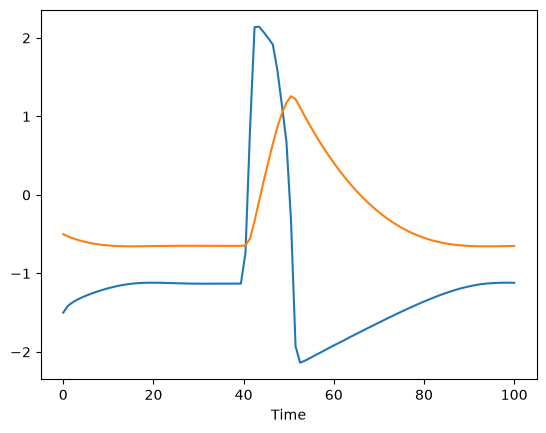

In [9]:
# Your code here.

I0 = 1.0
t_start = 40
t_stop = 47

def I(t):
    return I0*(t>t_start)*(t<t_stop)

e = 0.08
a = 1.0
b = 0.2
t_max = 100

def rhs(t,state):
    v,w = state
    dv_dt = v - (1/3)*v**3 - w + I(t)
    dw_dt = e*(v+a-b*w)

    return dv_dt, dw_dt

sol = solve_ivp(rhs, [0,t_max], [-1.5,-0.5], t_eval=np.linspace(0,100,100))    

T = sol.t
v,w = sol.y

fig, ax = plt.subplots()
ax.plot(T,v,label = 'v')
ax.plot(T,w,label = 'w')
ax.set_ylabel("")
ax.set_xlabel("Time")
plt.show()



## Part III: Ring of ten cells

Neurons are connected in a neural network. Suppose there are ten cells,
each with membrane potential and ion pump activity obeying the
FitzHugh-Nagumo equations for $v_i(t)$ and $w_i(t)$ where
$i=1 \ldots 10$ indexes the cells. The cells are electrically connected
so that

$$\begin{aligned}
\frac{dv_i}{dt} &= v_i - \frac{1}{3} v_i^3 - w_i + D\left( v_{i-1} - 2 v_i + v_{i+1}\right)\\
\frac{dw_i}{dt} &= \epsilon \left( v_i + a - bw_i\right)
\end{aligned}$$

where $D=0.9$ is a new parameter that describes the electrical
connectivity of the neighboring cells. The ion pumps are not connected
between cells, so the $w$ equation is unchanged. For simplicity, let’s
assume the cells are connected in a ring, so that

$$\frac{dv_1}{dt} = v_1 - \frac{1}{3} v_1^3 - w_1 + D\left( v_{10} - 2 v_1 + v_{2}\right)$$

and similarly for the tenth cell,

$$\frac{dv_{10}}{dt} = v_{10} - \frac{1}{3} v_{10}^3 - w_{10} + D\left( v_{9} - 2 v_{10} + v_{1}\right).$$

d.  Write code to simulate these ten cells. There will be 20 equations,
    $v$ and $w$ for each cell.

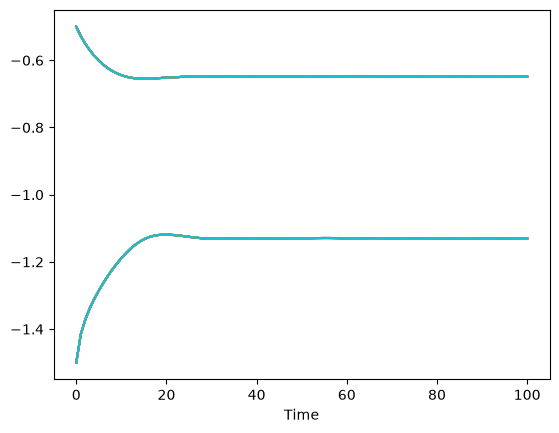

In [16]:
# Your code here.

I0 = 1.0
t_start = 40
t_stop = 47

def I(t):
    return I0*(t>t_start)*(t<t_stop)*0

D = 0.9
t_max = 100

def rhs(t,state):
    v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 = state
    dv1_dt = v1 - (1/3)*v1**3 - w1 + I(t) + D*(v10 - 2*v1 + v2)
    dv2_dt = v2 - (1/3)*v2**3 - w2 + I(t) + D*(v1 - 2*v2 + v3)
    dv3_dt = v3 - (1/3)*v3**3 - w3 + I(t) + D*(v2 - 2*v3 + v4)
    dv4_dt = v4 - (1/3)*v4**3 - w4 + I(t) + D*(v3 - 2*v4 + v5)
    dv5_dt = v5 - (1/3)*v5**3 - w5 + I(t) + D*(v4 - 2*v5 + v6)
    dv6_dt = v6 - (1/3)*v6**3 - w6 + I(t) + D*(v5 - 2*v6 + v7)
    dv7_dt = v7 - (1/3)*v7**3 - w7 + I(t) + D*(v6 - 2*v7 + v8)
    dv8_dt = v8 - (1/3)*v8**3 - w8 + I(t) + D*(v7 - 2*v8 + v9)
    dv9_dt = v9 - (1/3)*v9**3 - w9 + I(t) + D*(v8 - 2*v9 + v10)
    dv10_dt = v10 - (1/3)*v10**3 - w10 + I(t) + D*(v9 - 2*v10 + v1)
    dw1_dt = e*(v1+a-b*w1)
    dw2_dt = e*(v2+a-b*w2)
    dw3_dt = e*(v3+a-b*w3)
    dw4_dt = e*(v4+a-b*w4)
    dw5_dt = e*(v5+a-b*w5)
    dw6_dt = e*(v6+a-b*w6)
    dw7_dt = e*(v7+a-b*w7)
    dw8_dt = e*(v8+a-b*w8)
    dw9_dt = e*(v9+a-b*w9)
    dw10_dt = e*(v10+a-b*w10)

    return dv1_dt, dv2_dt,dv3_dt,dv4_dt,dv5_dt,dv6_dt,dv7_dt,dv8_dt,dv9_dt,dv10_dt,dw1_dt, dw2_dt,dw3_dt,dw4_dt,dw5_dt,dw6_dt,dw7_dt,dw8_dt,dw9_dt,dw10_dt

sol = solve_ivp(rhs, [0,t_max], [-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5], t_eval=np.linspace(0,100,100))    

T = sol.t
v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 = sol.y

fig, ax = plt.subplots()
ax.plot(T,v1,label = 'v1')
ax.plot(T,v2,label = 'v2')
ax.plot(T,v3,label = 'v3')
ax.plot(T,v4,label = 'v4')
ax.plot(T,v5,label = 'v5')
ax.plot(T,v6,label = 'v6')
ax.plot(T,v7,label = 'v7')
ax.plot(T,v8,label = 'v8')
ax.plot(T,v9,label = 'v9')
ax.plot(T,v10,label = 'v10')
ax.plot(T,w1,label = 'w1')
ax.plot(T,w2,label = 'w2')
ax.plot(T,w3,label = 'w3')
ax.plot(T,w4,label = 'w4')
ax.plot(T,w5,label = 'w5')
ax.plot(T,w6,label = 'w6')
ax.plot(T,w7,label = 'w7')
ax.plot(T,w8,label = 'w8')
ax.plot(T,w9,label = 'w9')
ax.plot(T,w10,label = 'w10')
ax.set_ylabel("")
ax.set_xlabel("Time")
plt.show()


i.  Note that that the above equations assume there is no injection
    current. We expect all ten cells to settle at the same steady state.
    Make two plots. First, plot a time series of the membrane potential
    of all ten cells as a function of time. Second, make a movie of the
    voltage in all ten cells, where the horizontal axis is the cell
    number.

``` python
# movie
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
(line,) = ax.plot(V[0])
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Cell")
ax.set_ylabel("Voltage")


def frame(nt):
    line.set_ydata(V[nt])
    return (line,)


movie = animation.FuncAnimation(fig, frame, frames=len(T), interval=30)
plt.close(fig)  # otherwise the first frame is drawn a second time, as a still
HTML(movie.to_jshtml())
```

where `V[nt]` is the voltage of all ten cells at time `T[nt]`.

In [17]:
# Your code here.

# movie
from matplotlib import animation
from IPython.display import HTML

V = np.array([v1,v2,v3,v4,v5,v6,v7,v8,v9,v10]).T
fig, ax = plt.subplots()
(line,) = ax.plot(V[0])
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Cell")
ax.set_ylabel("Voltage")


def frame(nt):
    line.set_ydata(V[nt])
    return (line,)


movie = animation.FuncAnimation(fig, frame, frames=len(T), interval=30)
plt.close(fig)  # otherwise the first frame is drawn a second time, as a still
HTML(movie.to_jshtml())


ii. Now assume that the fourth cell (and only the fourth cell) receives
    an injection current $I(t)$ as above, between $t=40$ and $t=47$.
    Note that this will require you to change the equation so that it
    has an $I$ term, like in Part II. Make a time series with all ten
    cells. Make a movie with the voltage for all cells.[1]

Hint: You do not need to make it generalize to different numbers of
cells. In other words, don’t try to make it work for an arbitrary number
of cells and then set the number of cells to 10. Just make it work for
10 cells. (Unless you want to make it generalized.)

[1] This type of behavior is called an *excitable traveling wave pulse*.
These are unlike the harmonic pulses familiar from sound waves,
vibrations, and light. For example, when two excitable pulses collide,
they annihilate.

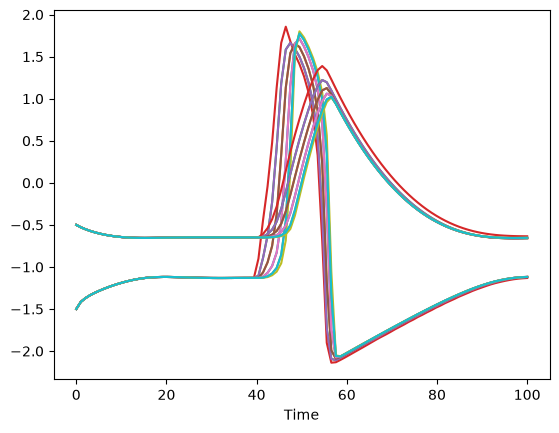

In [18]:
# Your code here.



I0 = 1.0
t_start = 40
t_stop = 47

def I(t):
    return I0*(t>t_start)*(t<t_stop)

D = 0.9
t_max = 100

def rhs(t,state):
    v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 = state
    dv1_dt = v1 - (1/3)*v1**3 - w1 + D*(v10 - 2*v1 + v2)
    dv2_dt = v2 - (1/3)*v2**3 - w2 + D*(v1 - 2*v2 + v3)
    dv3_dt = v3 - (1/3)*v3**3 - w3 + D*(v2 - 2*v3 + v4)
    dv4_dt = v4 - (1/3)*v4**3 - w4 + I(t) + D*(v3 - 2*v4 + v5)
    dv5_dt = v5 - (1/3)*v5**3 - w5 + D*(v4 - 2*v5 + v6)
    dv6_dt = v6 - (1/3)*v6**3 - w6 + D*(v5 - 2*v6 + v7)
    dv7_dt = v7 - (1/3)*v7**3 - w7 + D*(v6 - 2*v7 + v8)
    dv8_dt = v8 - (1/3)*v8**3 - w8 + D*(v7 - 2*v8 + v9)
    dv9_dt = v9 - (1/3)*v9**3 - w9 + D*(v8 - 2*v9 + v10)
    dv10_dt = v10 - (1/3)*v10**3 - w10 + D*(v9 - 2*v10 + v1)
    dw1_dt = e*(v1+a-b*w1)
    dw2_dt = e*(v2+a-b*w2)
    dw3_dt = e*(v3+a-b*w3)
    dw4_dt = e*(v4+a-b*w4)
    dw5_dt = e*(v5+a-b*w5)
    dw6_dt = e*(v6+a-b*w6)
    dw7_dt = e*(v7+a-b*w7)
    dw8_dt = e*(v8+a-b*w8)
    dw9_dt = e*(v9+a-b*w9)
    dw10_dt = e*(v10+a-b*w10)

    return dv1_dt, dv2_dt,dv3_dt,dv4_dt,dv5_dt,dv6_dt,dv7_dt,dv8_dt,dv9_dt,dv10_dt,dw1_dt, dw2_dt,dw3_dt,dw4_dt,dw5_dt,dw6_dt,dw7_dt,dw8_dt,dw9_dt,dw10_dt

sol = solve_ivp(rhs, [0,t_max], [-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5], t_eval=np.linspace(0,100,100))    

T = sol.t
v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 = sol.y

fig, ax = plt.subplots()
ax.plot(T,v1,label = 'v1')
ax.plot(T,v2,label = 'v2')
ax.plot(T,v3,label = 'v3')
ax.plot(T,v4,label = 'v4')
ax.plot(T,v5,label = 'v5')
ax.plot(T,v6,label = 'v6')
ax.plot(T,v7,label = 'v7')
ax.plot(T,v8,label = 'v8')
ax.plot(T,v9,label = 'v9')
ax.plot(T,v10,label = 'v10')
ax.plot(T,w1,label = 'w1')
ax.plot(T,w2,label = 'w2')
ax.plot(T,w3,label = 'w3')
ax.plot(T,w4,label = 'w4')
ax.plot(T,w5,label = 'w5')
ax.plot(T,w6,label = 'w6')
ax.plot(T,w7,label = 'w7')
ax.plot(T,w8,label = 'w8')
ax.plot(T,w9,label = 'w9')
ax.plot(T,w10,label = 'w10')
ax.set_ylabel("")
ax.set_xlabel("Time")
plt.show()


V = np.array([v1,v2,v3,v4,v5,v6,v7,v8,v9,v10]).T
fig, ax = plt.subplots()
(line,) = ax.plot(V[0])
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Cell")
ax.set_ylabel("Voltage")


def frame(nt):
    line.set_ydata(V[nt])
    return (line,)


movie = animation.FuncAnimation(fig, frame, frames=len(T), interval=30)
plt.close(fig)  # otherwise the first frame is drawn a second time, as a still
HTML(movie.to_jshtml())